In [1]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from typing import Annotated, TypedDict
from langchain_groq import ChatGroq
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from dotenv import load_dotenv
load_dotenv()

d:\Code\Python\AI\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [3]:
model = ChatGroq(model='llama-3.3-70b-versatile')

In [4]:
def chatbot(state: ChatState) -> dict:

        messages = state['messages']
        response = model.invoke(messages)
        return {'messages': response}

In [5]:
graph = StateGraph(ChatState)
checkpointer = MemorySaver()    #Used to save the state in RAM

graph.add_node('chatbot', chatbot)

graph.add_edge(START, 'chatbot')
graph.add_edge('chatbot', END)

chatbot = graph.compile(checkpointer=checkpointer)

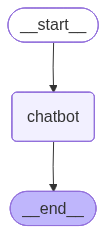

In [6]:
chatbot

In [7]:
thread_id = '1'

initial_state = {
    'messages': [
        HumanMessage(content='Hello, how are you?')
    ]
}

config = {
    'configurable': {
        'thread_id': thread_id
    }
}

response = chatbot.invoke(initial_state, config=config)

response

{'messages': [HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='803817e6-b5be-4ba8-b720-9535bc4a47b1'),
  AIMessage(content="Hello, I'm doing well, thanks for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you with any questions or tasks you may have. How can I help you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 57, 'prompt_tokens': 41, 'total_tokens': 98, 'completion_time': 0.14153866, 'completion_tokens_details': None, 'prompt_time': 0.007209424, 'prompt_tokens_details': None, 'queue_time': 0.05655415, 'total_time': 0.148748084}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e681b-31a3-70b2-9357-765cc703af35-0', tool_calls=[], invalid_tool_calls=[], usage_metadata=

In [11]:
thread_id = '1'

while True:

    user_input = input("You: ")
    if user_input.lower() in ['exit', 'quit']:
        print("Exiting the chatbot. Goodbye!")
        break

    
    config = {
        'configurable': {
            'thread_id': thread_id
        }
    }

    # Get the chatbot's response
    response = chatbot.invoke({ 'messages': [ HumanMessage(content=user_input) ] }, config=config)

    # Print the chatbot's response
    print(f"Chatbot: {response['messages'][-1].content}")

Chatbot: It's nice to see you again. Is there something on your mind that you'd like to talk about or ask, or would you like some conversation starters or fun facts to get us started? I'm here to listen and help.
Chatbot: I am a computer program designed to simulate conversation, answer questions, and provide information on a wide range of topics. I'm a type of artificial intelligence (AI) called a large language model, which means I've been trained on a massive dataset of text from the internet and can understand and respond to natural language inputs.

I don't have a personal identity or emotions like a human would, but I'm designed to be helpful and engaging. I can provide information, answer questions, tell stories, and even generate text on a given topic. I'm constantly learning and improving my responses based on the interactions I have with users like you.

Some of my capabilities include:

* Answering questions on a wide range of topics, from science and history to entertainmen

In [21]:
for message in chatbot.get_state(config=config).values['messages']:
    print(message)

content='Hello, how are you?' additional_kwargs={} response_metadata={} id='803817e6-b5be-4ba8-b720-9535bc4a47b1'
content="Hello, I'm doing well, thanks for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you with any questions or tasks you may have. How can I help you today?" additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 57, 'prompt_tokens': 41, 'total_tokens': 98, 'completion_time': 0.14153866, 'completion_tokens_details': None, 'prompt_time': 0.007209424, 'prompt_tokens_details': None, 'queue_time': 0.05655415, 'total_time': 0.148748084}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019e681b-31a3-70b2-9357-765cc703af35-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 41, 'output_tokens': 57, 'total_t

### Streaming Text From The Model

In [10]:
stream = chatbot.stream(
    {'messages': [HumanMessage(content="Receipe of pasta with tomato sauce")]},
    config={'configurable': {'thread_id': 'thread_1'}},
    stream_mode='messages'
)

print(type(stream))  #GeneratorType

for message_chunks, metadata in stream:
    if message_chunks.content:
        print(message_chunks.content, end=" ", flush=True)

<class 'generator'>
A  classic  Italian  dish .  Here 's  a  simple  recipe  for  pasta  with  tomato  sauce :

 ** Ingredients : **

 *   500 g  pasta  of  your  choice  ( e .g .,  spaghetti ,  pen ne ,  fus illi ,  or  rig at oni )
 *   2  tablespoons  olive  oil 
 *   1  onion ,  finely  chopped 
 *   3  garlic  cloves ,  minced 
 *   2  cups  fresh  or  canned  crushed  tomatoes  ( San  Mar zano  or  similar )
 *   1  teaspoon  dried  basil 
 *   1  teaspoon  dried  o reg ano 
 *  Salt  and  pepper ,  to  taste 
 *  Gr ated  Parm esan  cheese ,  for  serving  ( optional )
 *  Fresh  basil  leaves ,  for  garn ish  ( optional )

 ** Instructions : **

 1 .  ** Cook  the  pasta **:  Bring  a  large  pot  of  salt ed  water  to  a  boil .  Cook  the  pasta  according  to  the  package  instructions  until  al  d ente .  Reserve   1  cup  of  pasta  water  before  draining .
 2 .  ** S auté  the  onion  and  garlic **:  In  a  large  sauce pan ,  heat  the  olive  oil  over  medium  he